# Assignment 2 - Analysing Data

In this assignment, I will investigate whether specific storytelling features can predict the overall story strength score in posts from the *ChangeMyView* dataset. Using the data, simple linear regression will be performed to examine the relationship between the `story_score` (dependent variable) and several narrative features: `agency_score`, `event_score`, `world_score`, `curiosity_score`, `surprise_score`, and `suspense_score` (independent variables).

The analysis includes visualizing the data with scatterplots (step 1), performing Simple Linear Regression (step 2), plotting a function for each independent variable using the slope and intercept (step 3), calculating R² scores (step 4), analyzing residual plots (step 5), and testing the normality of residuals using the Shapiro–Wilk test (step 6). 

This notebook contains the code for the assignment, with some minimal explenation/analysis. For a full report, I refer to my github: 
https://github.com/liseferinga/Analysing-Data/tree/main 

## Step 1. Scatterplot

In order to conclude which variable is the most related to the overall story score, I will begin with an overview of the data. Scatterplots tells us about how strongly each feature might predict `story_score`. The x-cordinate represents the the value of the independent variable (e.g., `agency_score`), and the y-cordinate represents the `story_score` for the same story. So if a dot is at (3, 0.8), that post has an agency score of 3 and a story score of 0.8. 

> How to read a scatterplot:
>
> | Pattern | Suggests |
|--------|----------|
| Upward trend (dots slope up) | As the feature increases, `story_score` tends to increase → possible positive predictor |
| Downward trend (dots slope down) | As the feature increases, `story_score` tends to decrease → possible negative predictor |
| Very scattered / no pattern | No clear relationship → feature likely a weak predictor |
| Tightly clustered along a line | Stronger predictor; regression will likely have a higher R² |
| Horizontal cluster | No predictive value (slope ≈ 0) |

### 1.1 Importing 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### 1.2 Creating the Dataframe 

In [2]:
df = pd.read_csv("data_full_story.csv") 
print(df.head())

         name  story_score  agency_score  event_score  world_score  \
0  t1_c95k50u     0.000000           1.0          1.0     1.000000   
1  t1_c95mz3n     0.857143           4.0          5.0     1.000000   
2  t1_c95l4my     0.857143           4.0          4.0     1.000000   
3  t1_c95mcms     0.857143           5.0          5.0     1.000000   
4   t3_1aenyc     1.000000           5.0          5.0     3.666667   

   suspense_score  surprise_score  curiosity_score  
0            2.75            2.25             1.75  
1            2.75            2.75             3.25  
2            2.75            3.25             3.50  
3            3.25            4.00             2.50  
4            2.75            3.50             3.75  


### 1.3 Creating a Scatterplot for Each Independent Variable 

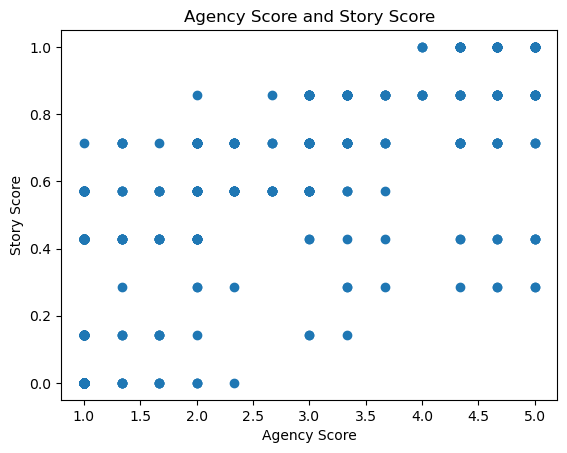

In [3]:
x = df["agency_score"]
y = df["story_score"]

plt.scatter(x, y)
plt.xlabel("Agency Score")
plt.ylabel("Story Score")
plt.title("Agency Score and Story Score")
plt.show()

> `agency_score`: points mostly increase from left to right, some outliers; looks like diagonal blocks. Slight positive trend (but the outliers reduce confidence).

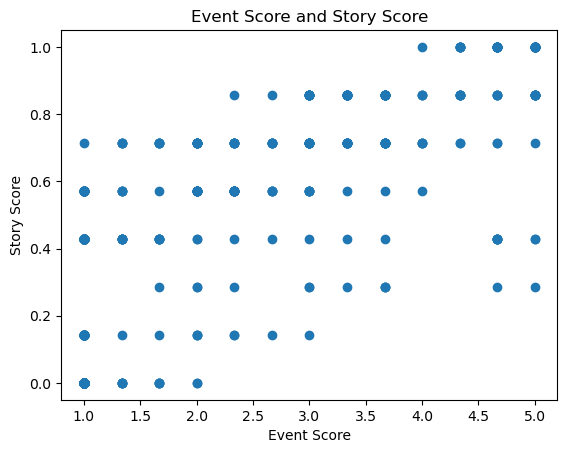

In [4]:
x = df["event_score"]
y = df["story_score"]

plt.scatter(x, y)
plt.xlabel("Event Score")
plt.ylabel("Story Score")
plt.title("Event Score and Story Score")
plt.show()


> `event_score`: similar to `agency_score`, even closer together; slight positive trend (more consistant than `agency_score`). 

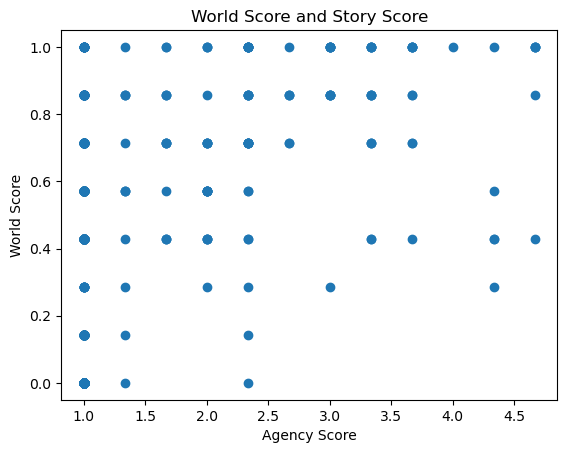

In [5]:
x = df["world_score"]
y = df["story_score"]

plt.scatter(x, y)
plt.xlabel("Agency Score")
plt.ylabel("World Score")
plt.title("World Score and Story Score")
plt.show()

> `world_score`: points cluttered at top-left, then scattered across the plot. No clear linear trend. 

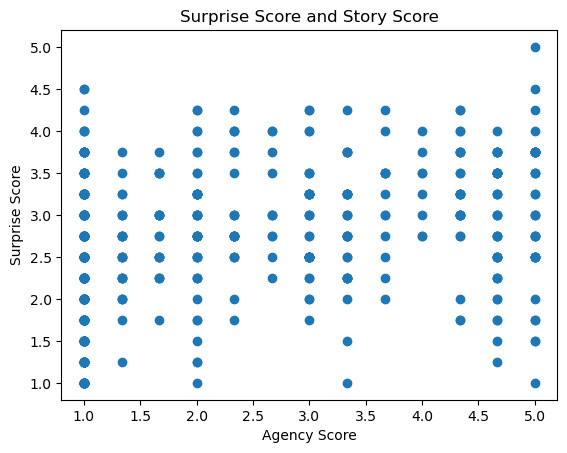

In [6]:
x = df["agency_score"]
y = df["surprise_score"]

plt.scatter(x, y)
plt.xlabel("Agency Score")
plt.ylabel("Surprise Score")
plt.title("Surprise Score and Story Score")
plt.show()

> `suprise_score`: vertical lines, multiple suspense values for same `story_score`; scattered. No clear linear trend. 

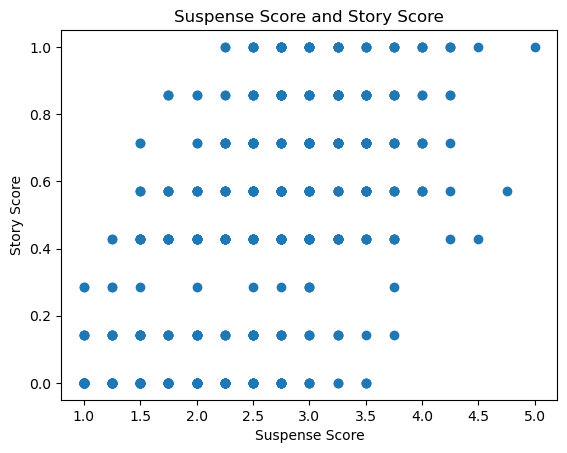

In [7]:
x = df["suspense_score"]
y = df["story_score"]

plt.scatter(x, y)
plt.xlabel("Suspense Score")
plt.ylabel("Story Score")
plt.title("Suspense Score and Story Score")
plt.show()

> `suspense_score`: horizontal lines, upward trend from left to right. Slight positive trend (may have some predictive value, but scatter is large). 

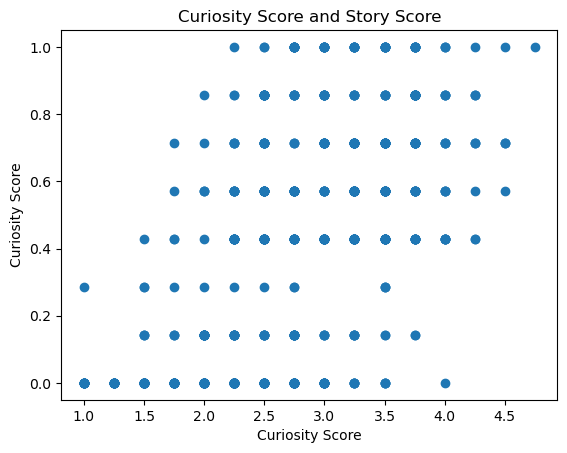

In [8]:
x = df["curiosity_score"]
y = df["story_score"]

plt.scatter(x, y)
plt.xlabel("Curiosity Score")
plt.ylabel("Curiosity Score")
plt.title("Curiosity Score and Story Score")
plt.show()

> `curiosity_score`: similar to `suspense_score`: horizontal lines, multiple story_scores per feature value; upward trend.

## Step 2. Simple Linear Regression

Simple linear regression is a statistical method to model the relationship between two variables. We can use this method to visualize the relationship between two variables by fitting a straight line that predicts the dependent variable (story score) based on the independent variable’s values, showing both the direction and strength of the association. 

> The **slope** of the line indicates how strongly the independent variable affects the dependent variable.

> The **intercept** represents the predicted value of story_score when the independent variable equals zero

### 2.1 Importing

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

### 2.2 Establishing the Dataframe

In [10]:
df = pd.read_csv("data_full_story.csv")

### 2.3 Performing Simple Linear Regression

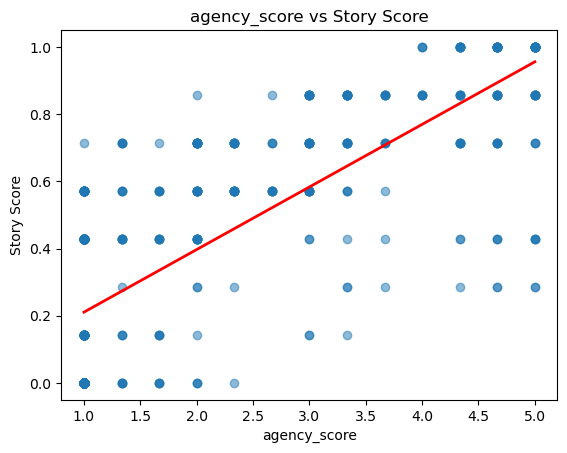

Feature: agency_score, Slope: 0.186, Intercept: 0.024


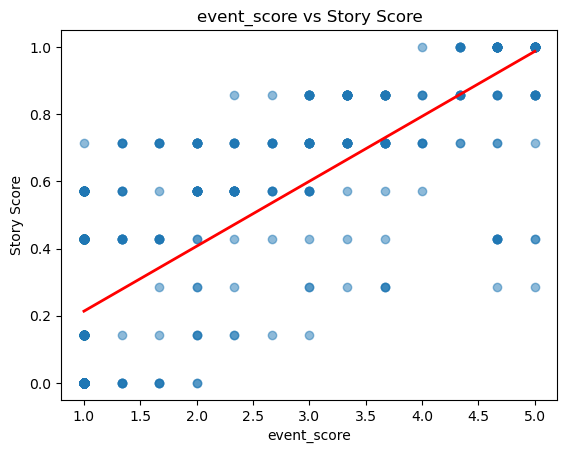

Feature: event_score, Slope: 0.193, Intercept: 0.020


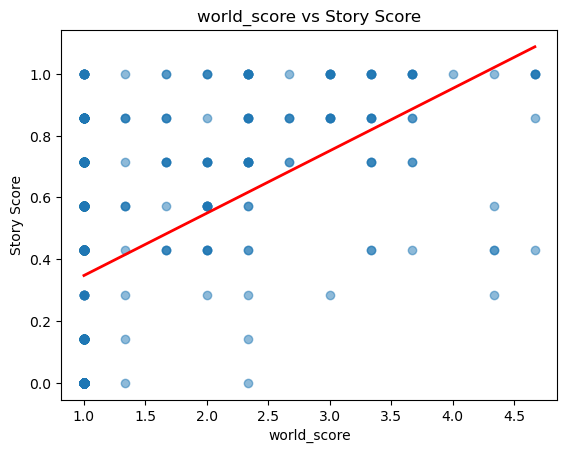

Feature: world_score, Slope: 0.202, Intercept: 0.145


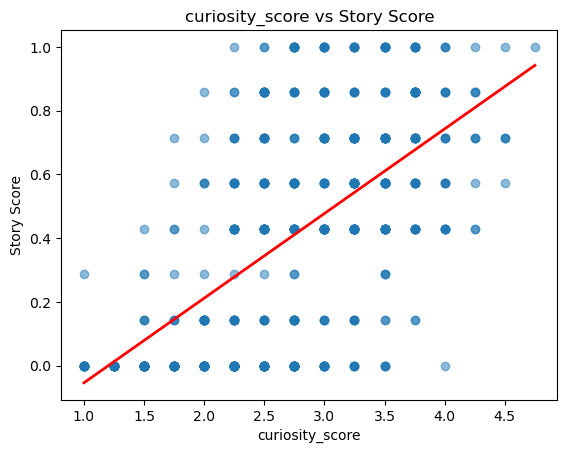

Feature: curiosity_score, Slope: 0.265, Intercept: -0.319


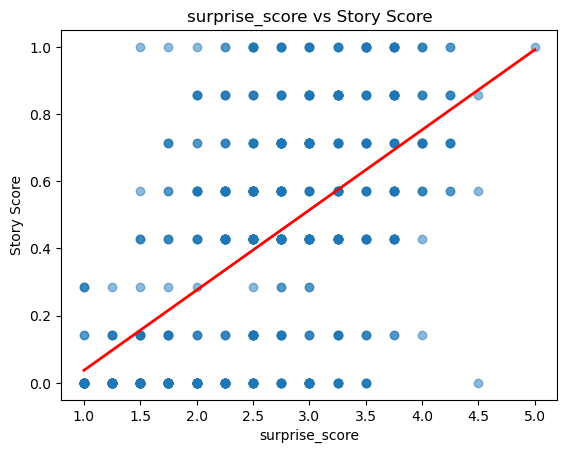

Feature: surprise_score, Slope: 0.239, Intercept: -0.201


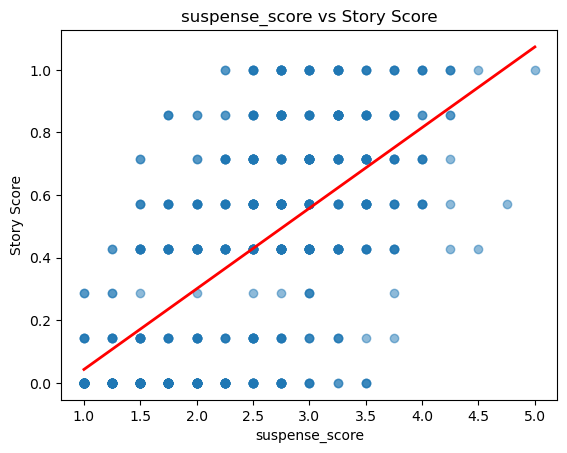

Feature: suspense_score, Slope: 0.258, Intercept: -0.215


In [11]:
features = ["agency_score", "event_score", "world_score", "curiosity_score", "surprise_score", "suspense_score"]
y = df["story_score"].values

for feature in features:
    x = df[feature].values
    y = df["story_score"].values
    m, b = np.polyfit(x, y, 1)
    y_pred = m*x + b
    
    plt.scatter(x, y, alpha=0.5)
    plt.plot(np.sort(x), m*np.sort(x) + b, color='red', linewidth=2)
    plt.xlabel(feature)
    plt.ylabel("Story Score")
    plt.title(f"{feature} vs Story Score")
    plt.show()
    
    print(f"Feature: {feature}, Slope: {m:.3f}, Intercept: {b:.3f}")

## Step 3. Calculating the R2 score 

The R² score (coefficient of determination) measures how well the independent variable explains the variation in the dependent variable. Calculating the R² value will give us a way to establish how much of the change in story_score can be 'explained' by the feature. 

| R² value | Interpretation |
|----------|----------------|
| **R² = 1** | The regression line perfectly explains all variation in the dependent variable. |
| **R² = 0** | The regression line explains none of the variation; the independent variable does not predict the dependent variable. |


### 3.1 Importing

In [12]:
import numpy as np
from sklearn.metrics import r2_score

### 3.2 Calculating R2 Score Using sklearn.metrics Function

In [13]:
features = ["agency_score", "event_score", "world_score", "curiosity_score", "surprise_score", "suspense_score"]
y = df["story_score"].values

for feature in features:
    x = df[feature].values
    m, b = np.polyfit(x, y, 1)
    y_pred = m*x + b
    r2 = r2_score(y, y_pred)
    print(f"{feature}: R² = {r2:.3f}")

agency_score: R² = 0.581
event_score: R² = 0.597
world_score: R² = 0.204
curiosity_score: R² = 0.361
surprise_score: R² = 0.343
suspense_score: R² = 0.421


## Step 4. Residuals 

The residuals are the differences between the actual values and the predicted values from the simple linear regression. Randomly scattered residuals indicate a good linear fit, while systematic patterns or large deviations indicate poor fit or that the feature is a weak predictor.

### 4.1 Importing

In [14]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### 4.2 Calculating and Plotting Residuals 

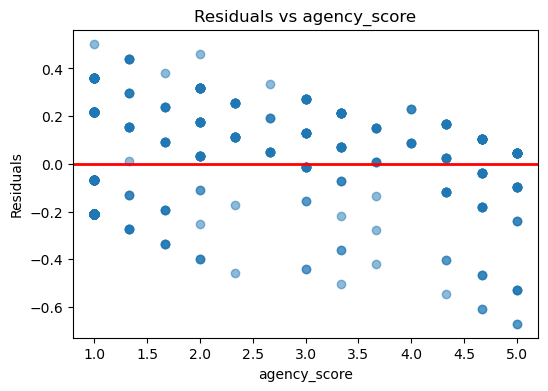

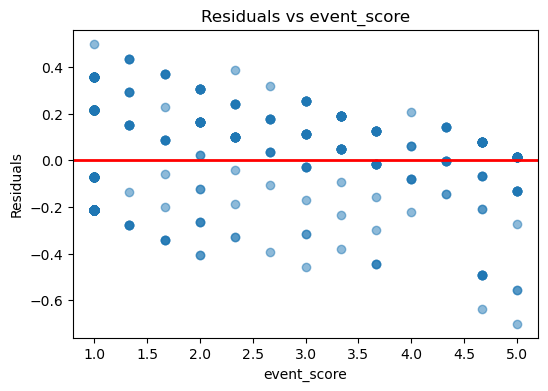

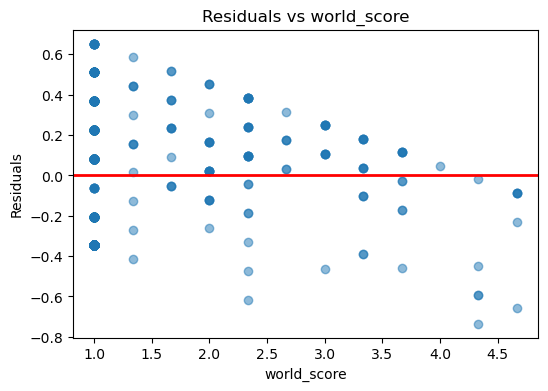

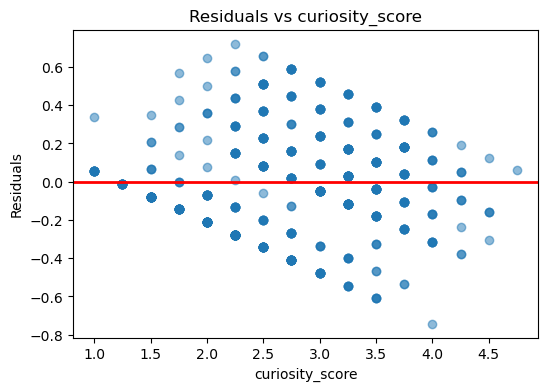

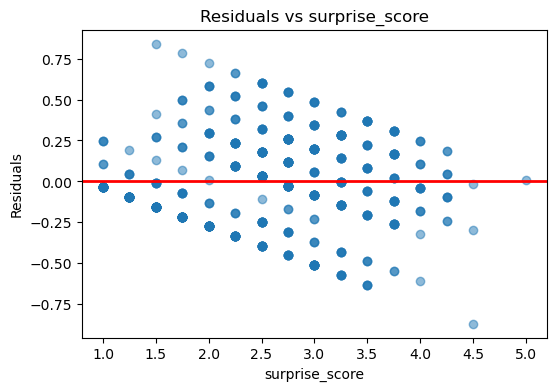

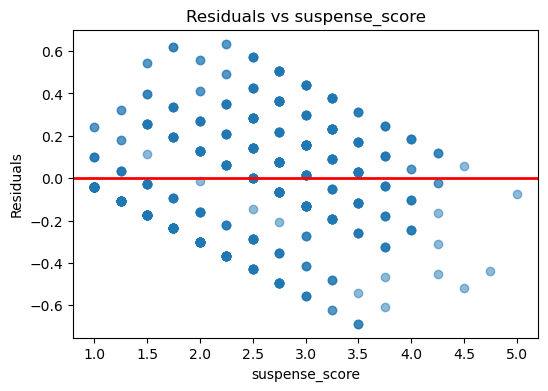

In [15]:
features = ["agency_score", "event_score", "world_score", "curiosity_score", "surprise_score", "suspense_score"]
y = df["story_score"].values

for feature in features:
    X = df[feature].values.reshape(-1,1)
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    residuals = y - y_pred
    
    # Plot residuals
    plt.figure(figsize=(6,4))
    plt.scatter(X, residuals, alpha=0.5)
    plt.axhline(0, color='red', linewidth=2)
    plt.xlabel(feature)
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs {feature}")
    plt.show()

## Step 5. Shapiro-Wilk Test

### 5.1 Importing

The Shapiro–Wilk test checks whether the residuals are normally distributed. This is important since if they are norally distributed, we can safely make assuptions.

In [16]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy import stats

### 5.2 Calculating the p-value

In [17]:
df = pd.read_csv("data_full_story.csv")
features = ["agency_score", "event_score", "world_score", "curiosity_score", "surprise_score", "suspense_score"]
y = df["story_score"].values

for feature in features:
    X = df[feature].values.reshape(-1,1)
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    residuals = y - y_pred
    
    # Shapiro-Wilk test
    shapiro_test = stats.shapiro(residuals)
    W, p_value = shapiro_test
    
    print(f"{feature}: Shapiro-Wilk W={W:.3f}, p={p_value:.3f}")

agency_score: Shapiro-Wilk W=0.943, p=0.000
event_score: Shapiro-Wilk W=0.943, p=0.000
world_score: Shapiro-Wilk W=0.914, p=0.000
curiosity_score: Shapiro-Wilk W=0.989, p=0.000
surprise_score: Shapiro-Wilk W=0.996, p=0.072
suspense_score: Shapiro-Wilk W=0.994, p=0.018
